In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cleaned_sales.csv')

In [23]:
df["sales_representative"].value_counts()

sales_representative
Sophia Brown        1158
Olivia Martin       1143
Emma Carter         1143
Amelia Jackson      1142
Michael Clark       1142
Lucas Moore         1133
Noah Wilson         1121
Henry White         1121
Grace Harris        1119
Mia Taylor          1116
James Anderson      1108
Liam Davis          1108
Daniel Miller       1095
Ella Lewis          1093
Charlotte Thomas    1071
David Walker        1067
Name: count, dtype: int64

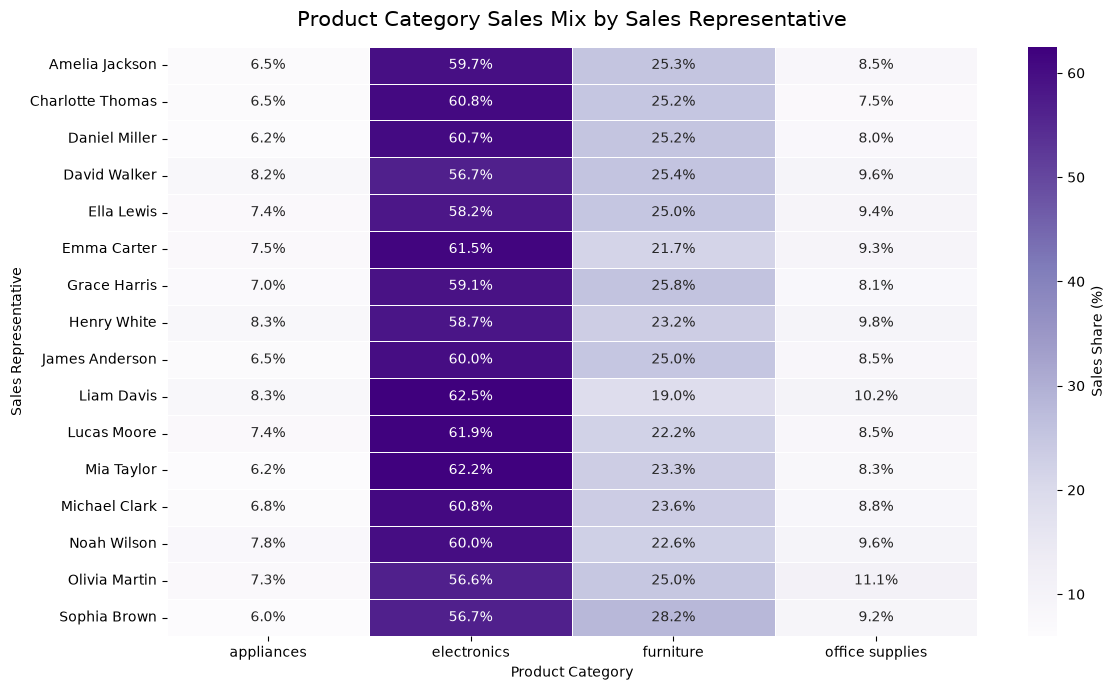

In [43]:
rep_category = (
    df.groupby(["sales_representative", "product_category"])["sales_amount"]
      .sum()
      .unstack(fill_value=0)
)

rep_share = rep_category.div(rep_category.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 7))

sns.heatmap(
    rep_share,
    annot=rep_share.map(lambda x: f"{x:.1f}%"),
    fmt="",
    cmap="Purples",
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"label": "Sales Share (%)"}
)

plt.title(
    "Product Category Sales Mix by Sales Representative",
    fontsize=15,
    pad=15
)

plt.xlabel("Product Category")
plt.ylabel("Sales Representative")

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
df["age_group"] = pd.cut(
    df["customer_age"],
    bins=[14, 22, 30, 50, float("inf")],
    labels=["Teenagers", "Young Adults", "Middle Age", "Older Adults"]
)

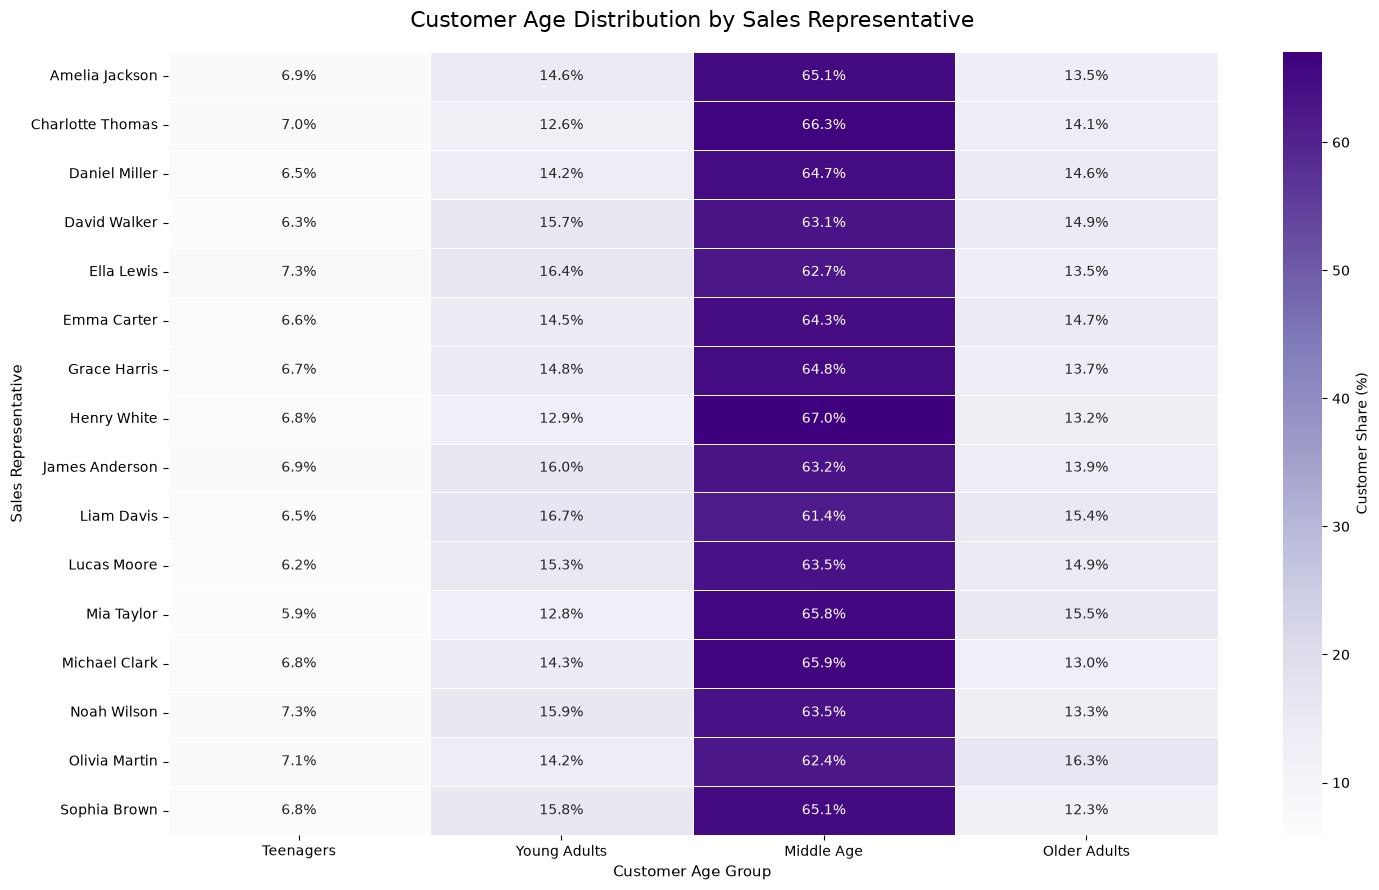

In [ ]:
age_rep = (
    df.groupby(["sales_representative", "age_group"])["customer_id"]
      .nunique()
      .unstack(fill_value=0)
)

age_rep_pct = age_rep.div(age_rep.sum(axis=1), axis=0) * 100

plt.figure(figsize=(15, 9))

sns.heatmap(
    age_rep_pct,
    annot=age_rep_pct.map(lambda x: f"{x:.1f}%"),
    fmt="",
    cmap="Purples",
    linewidths=0.7,
    linecolor="white",
    cbar_kws={"label": "Customer Share (%)"}
)

plt.title(
    "Customer Age Distribution by Sales Representative",
    fontsize=16,
    pad=18
)

plt.xlabel("Customer Age Group", fontsize=11)
plt.ylabel("Sales Representative", fontsize=11)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

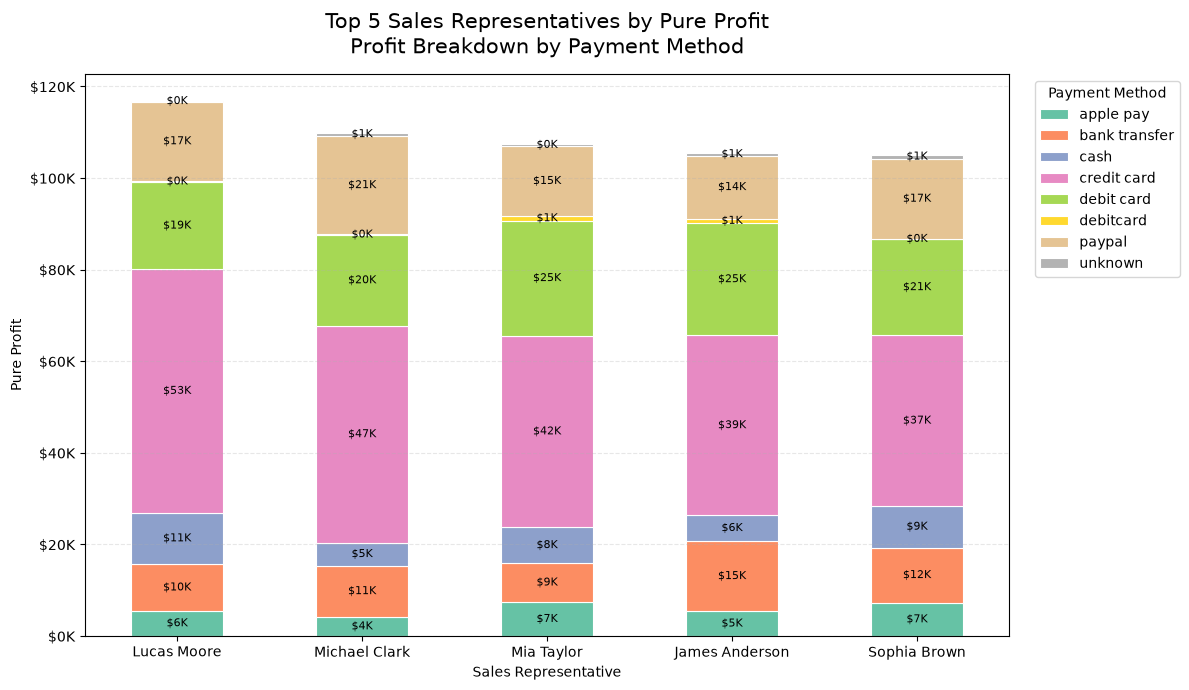

In [44]:
from matplotlib.ticker import FuncFormatter

df["pure_profit"] = df["sales_amount"] - df["cost_amount"]

top_reps = (
    df.groupby("sales_representative")["pure_profit"]
      .sum()
      .nlargest(5)
      .index
)

plot_df = (
    df[df["sales_representative"].isin(top_reps)]
    .groupby(["sales_representative", "payment_method"])["pure_profit"]
    .sum()
    .unstack(fill_value=0)
)

plot_df = plot_df.loc[
    plot_df.sum(axis=1).sort_values(ascending=False).index
]

colors = sns.color_palette("Set2", n_colors=len(plot_df.columns))

ax = plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7),
    color=colors,
    edgecolor="white",
    linewidth=0.8
)


def money_fmt(x):
    if abs(x) >= 1_000_000:
        return f"${x / 1_000_000:.1f}M"
    return f"${x / 1_000:.0f}K"


for container in ax.containers:
    labels = [
        money_fmt(v) if v > 0 else ""
        for v in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=8,
        color="black"
    )


ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: money_fmt(x))
)

plt.title(
    "Top 5 Sales Representatives by Pure Profit\n"
    "Profit Breakdown by Payment Method",
    fontsize=15,
    pad=15
)

plt.xlabel("Sales Representative")
plt.ylabel("Pure Profit")

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.legend(
    title="Payment Method",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()